In [1]:
# patch mammos_dft
import ase.io
import mammos_dft
import mammos_units as u


def _get_unit_cell_vectors(material):
    if material != "Co2Fe2H4":
        raise NotImplementedError(f"Material {material} not supported")
    cif_file = mammos_dft.db.DATA_DIR / "0001" / "structure.cif"
    atoms = ase.io.read(cif_file)
    return atoms.cell * u.Angstrom


mammos_dft.db.get_unit_cell_vectors = _get_unit_cell_vectors

# Computing temperature-dependent intrinsic parameters (Python interface to UppASD)

In this notebook we show how we can get temperature dependent Ms, A, and K by running spindynamics simulations for a range of temperatures and then fitting the Kuzmin equation to the resulting M(T). From the fit we can get A(T) and K(T).

After that we discuss different possibilities to extract Tc from the spindynamics simulations.

:::{warning}
In order to keep the runtime for this notebook short, we will use small values for `ncell`, `ip_mcnstep` and `mcnstep`. For production calculations you should choose larger values.
:::

In [30]:
import mammos_analysis
import mammos_dft
import mammos_entity as me
import mammos_spindynamics
import matplotlib.pyplot as plt
import numpy as np

## Creating the simulation object

First, we need to create a simulation object. We assume that we already have three files `posfile`, `momfile` and `jfile` in our current working directory and that they are in the form required for UppASD. We will not create `inpsd.dat` manually but instead rely on the simulation object. We can pass all required options for the input file as arguments when creating the simulation object or when calling one of its functions. Here, we will pass most arguments at creation time and only temperature values at runtime.

We take TODO as an example for this notebook.

In [3]:
material = "Fe2.33Ta0.67Y"

In [4]:
material = "Co2Fe2H4"

In [5]:
# TODO should this come from mammos_dft?
material_inputs = mammos_spindynamics.db.get_material(material)

In [6]:
unit_cell_vectors = mammos_dft.db.get_unit_cell_vectors(material)
unit_cell_vectors.value

array([[ 2.645345  ,  0.        ,  0.        ],
       [-1.32267223,  2.29090033,  0.        ],
       [ 0.        ,  0.        ,  8.539476  ]])

In [9]:
simulation = mammos_spindynamics.uppasd.Simulation(
    cell=unit_cell_vectors.value.tolist(),
    alat=unit_cell_vectors.unit.to("m"),
    ncell=(16, 16, 16),
    posfile=material_inputs.posfile,
    posfiletype="D",
    momfile=material_inputs.momfile,
    maptype=2,
    exchange=material_inputs.jfile,
    initmag=3,
    ip_mcnstep=250,
    mcnstep=500,
)
simulation

Simulation(
    inpsd_dat=None,
    ncell=(16, 16, 16),
    ip_mcnstep=250,
    mcnstep=500,
    cell=[[2.645345, 0.0, 0.0], [-1.3226722338393606, 2.290900329657839, 0.0], [0.0, 0.0, 8.539476]],
    alat=1.0000000000000002e-10,
    posfile=PosixPath('/home/mlang/repos/mammos/mammos-devtools/packages/mammos-spindynamics/src/mammos_spindynamics/data/0001/posfile'),
    posfiletype='D',
    momfile=PosixPath('/home/mlang/repos/mammos/mammos-devtools/packages/mammos-spindynamics/src/mammos_spindynamics/data/0001/momfile'),
    maptype=2,
    exchange=PosixPath('/home/mlang/repos/mammos/mammos-devtools/packages/mammos-spindynamics/src/mammos_spindynamics/data/0001/jfile'),
    initmag=3,
)

## Running a temperature sweep

We now want to run simulations for a series of temperatures between 50 and 1500 Kelvin, in steps of 200 Kelvin. We can use the `range` function to get all temperatures. The simulation object provides a method to automatically run all simulations sequentially.

TODO We can tell it to use the restart file of the previous calculation as starting point for the next simulation. For the first simulation it will use `Initmag=1`, which we have set above.

In [14]:
coarse_sweep = simulation.temperature_sweep(T=range(50, 1500, 200), out=material)

Running simulations for 8 different temperatures:
    [50, 250, 450, 650, 850, 1050, 1250, 1450]
Running UppASD in Co2Fe2H4/3-temperature_sweep/0-run ... simulation finished, took 0:00:09
Running UppASD in Co2Fe2H4/3-temperature_sweep/1-run ... simulation finished, took 0:00:09
Running UppASD in Co2Fe2H4/3-temperature_sweep/2-run ... simulation finished, took 0:00:10
Running UppASD in Co2Fe2H4/3-temperature_sweep/3-run ... simulation finished, took 0:00:09
Running UppASD in Co2Fe2H4/3-temperature_sweep/4-run ... simulation finished, took 0:00:10
Running UppASD in Co2Fe2H4/3-temperature_sweep/5-run ... simulation finished, took 0:00:10
Running UppASD in Co2Fe2H4/3-temperature_sweep/6-run ... simulation finished, took 0:00:09
Running UppASD in Co2Fe2H4/3-temperature_sweep/7-run ... simulation finished, took 0:00:09


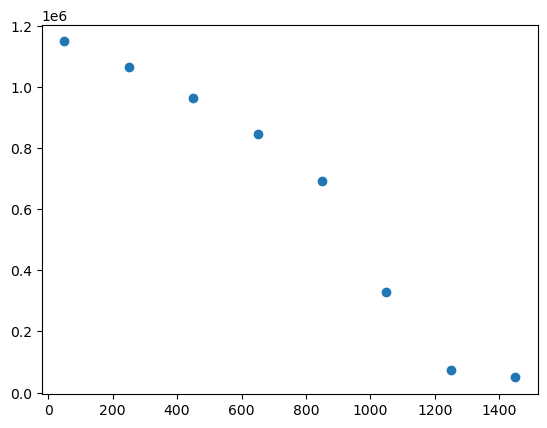

In [63]:
plt.plot(coarse_sweep.T.value, coarse_sweep.Ms.value, "o")

## Refining data around Tc

From the few simulations we can see that Tc is somewhere around 1200 K. We now run a second sweep with a finer spacing of 200 Kelvin, to beter resolve the area around Tc. We can restart the simulation from the result at 1050 K.

In [16]:
coarse_sweep.sel(T=1050)

IndexError: single positional indexer is out-of-bounds

In [19]:
coarse_sweep[5].restartfile

PosixPath('Co2Fe2H4/3-temperature_sweep/5-run/restart._UppASD_.out')

In [21]:
simulation.temperature_sweep(
    T=range(1070, 1250, 20),
    out=material,
    initmag=4,
    restartfile=coarse_sweep[5].restartfile,
);

Running simulations for 9 different temperatures:
    [1070, 1090, 1110, 1130, 1150, 1170, 1190, 1210, 1230]


## Analyzing simulation output

First, we create a data object, which we point to the top-level output directory `...`. The object recursively finds all files in `...` and provides access to the simulation results from within Python.

In [22]:
data = mammos_spindynamics.uppasd.read(material)
data.info()

KeyError: 'time_elapsed'

In [ ]:
coarse_sweep = data[0]
fine_sweep = data[1]

In [25]:
coarse_sweep = mammos_spindynamics.uppasd.read(f"{material}/0-temperature_sweep")
fine_sweep = mammos_spindynamics.uppasd.read(f"{material}/1-temperature_sweep")

In [26]:
coarse_sweep = mammos_spindynamics.uppasd.read(f"{material}/3-temperature_sweep")
fine_sweep = mammos_spindynamics.uppasd.read(f"{material}/4-temperature_sweep")

In [28]:
coarse_sweep.info()

,name,description,time_elapsed,T,initmag,restartfile
0,0-run,,0:00:09,50,NaN,NaN
1,1-run,,0:00:09,250,4,Co2Fe2H4/3-temperature_sweep/0-run/restart._Up...
2,2-run,,0:00:10,450,4,Co2Fe2H4/3-temperature_sweep/1-run/restart._Up...
3,3-run,,0:00:09,650,4,Co2Fe2H4/3-temperature_sweep/2-run/restart._Up...
4,4-run,,0:00:10,850,4,Co2Fe2H4/3-temperature_sweep/3-run/restart._Up...
5,5-run,,0:00:10,1050,4,Co2Fe2H4/3-temperature_sweep/4-run/restart._Up...
6,6-run,,0:00:09,1250,4,Co2Fe2H4/3-temperature_sweep/5-run/restart._Up...
7,7-run,,0:00:09,1450,4,Co2Fe2H4/3-temperature_sweep/6-run/restart._Up...


In [29]:
fine_sweep.info()

,name,description,time_elapsed,T,initmag,restartfile,verbose
0,0-run,,0:00:09,1070,4,Co2Fe2H4/3-temperature_sweep/5-run/restart._Up...,2
1,1-run,,0:00:10,1090,4,Co2Fe2H4/4-temperature_sweep/0-run/restart._Up...,2
2,2-run,,0:00:11,1110,4,Co2Fe2H4/4-temperature_sweep/1-run/restart._Up...,2
3,3-run,,0:00:12,1130,4,Co2Fe2H4/4-temperature_sweep/2-run/restart._Up...,2
4,4-run,,0:00:10,1150,4,Co2Fe2H4/4-temperature_sweep/3-run/restart._Up...,2
5,5-run,,0:00:10,1170,4,Co2Fe2H4/4-temperature_sweep/4-run/restart._Up...,2
6,6-run,,0:00:11,1190,4,Co2Fe2H4/4-temperature_sweep/5-run/restart._Up...,2
7,7-run,,0:00:11,1210,4,Co2Fe2H4/4-temperature_sweep/6-run/restart._Up...,2
8,8-run,,0:00:09,1230,4,Co2Fe2H4/4-temperature_sweep/7-run/restart._Up...,2


In [49]:
T_combined = me.concat_flat(coarse_sweep.T.value[:6], fine_sweep.T, coarse_sweep.T.value[6:])
Ms_combined = me.concat_flat(coarse_sweep.Ms.value[:6], fine_sweep.Ms, coarse_sweep.Ms.value[6:])

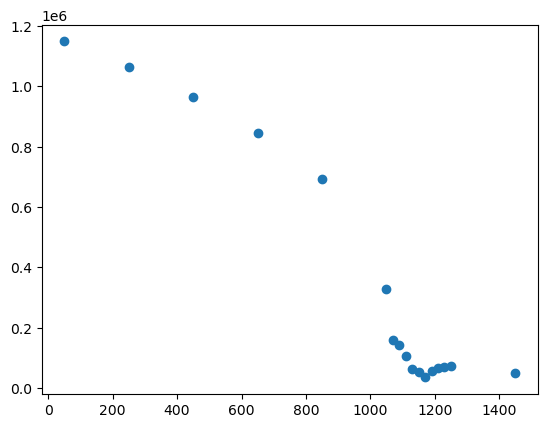

In [52]:
plt.plot(T_combined.value, Ms_combined.value, "o")

For this material pre-computed values for Ms are available in the database. We can compare the two to see how much we loos in accuracy by using only very few samples:

<Axes: xlabel='Thermodynamic Temperature (K)', ylabel='Spontaneous Magnetization (A / m)'>

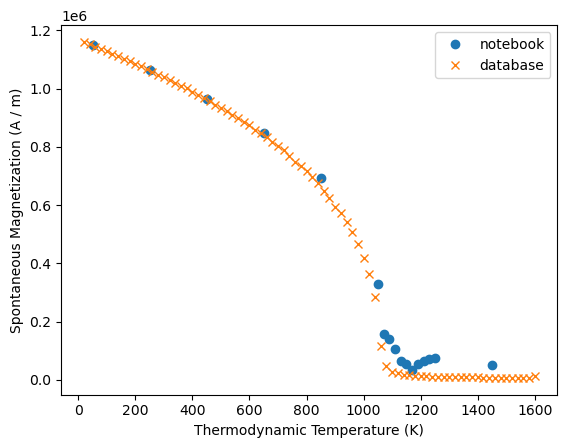

In [66]:
plt.plot(T_combined.value, Ms_combined.value, "o", label="notebook")
material_inputs.magnetization_data.plot(ax=plt.gca(), label="database")

## Kuzmin fit

We can now pass the data from the temperature sweep to the Kuzmin function in `mammos_analysis`:

In [8]:
# anisotropy constant at T=0K from DFT
results_dft = mammos_dft.db.get_micromagnetic_properties(material)

MicromagneticProperties(Ms_0=Entity(ontology_label='SpontaneousMagnetization', value=np.float64(1190240.2412648), unit='A / m'), Ku_0=Entity(ontology_label='UniaxialAnisotropyConstant', value=np.float64(2810000.0), unit='J / m3'))

In [58]:
kuzmin_result = mammos_analysis.kuzmin.kuzmin_properties(
    T=T_combined, Ms=Ms_combined, K1_0=results_dft.Ku_0
)  # TODO is Ku correct???

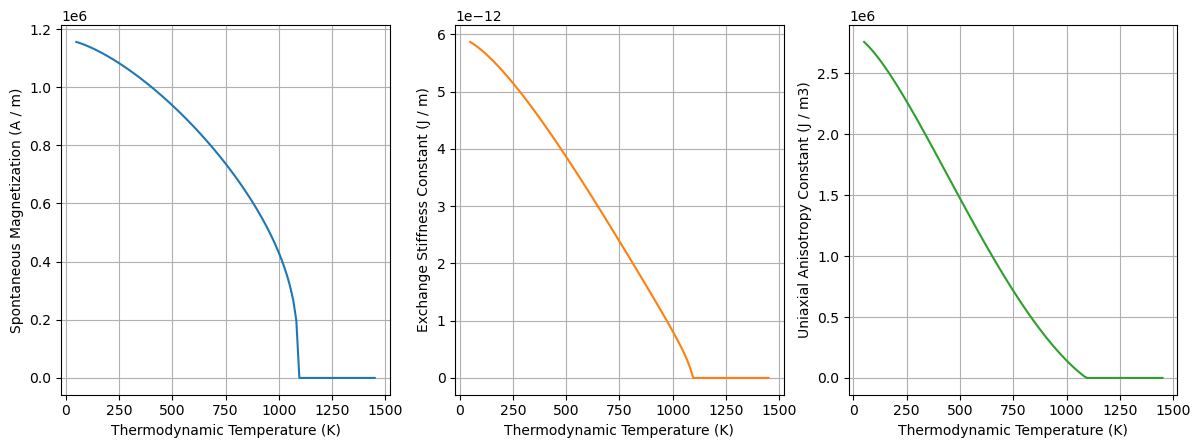

In [61]:
kuzmin_result.plot();

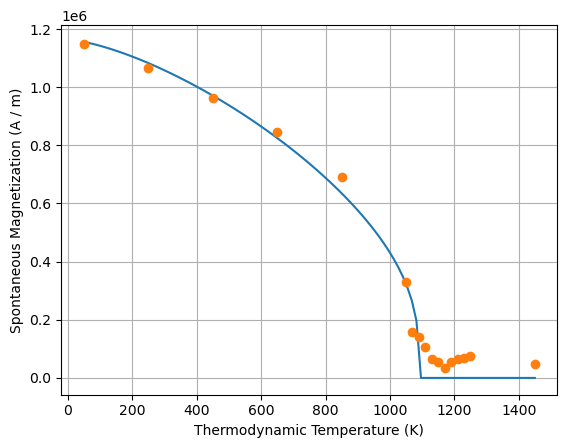

In [62]:
kuzmin_result.Ms.plot()
plt.plot(T_combined.value, Ms_combined.value, "o")

We could use results from the Kuzmin fit as inputs for a micromagnetic simulation, e.g. to access parameters at 300 Kelvin (for which we did not run a simulation) we can use:

In [ ]:
kuzmin_result.Ms(300)

In [ ]:
kuzmin_result.A(300)

## Estimating Tc

We can use the simulation results also to estimate Tc using different methods:
- Tc fit parameter returned from Kuzmin
- Peak in the specific heat at Tc
- Crossing of Binder cumulants at Tc when running simulations for different system sizes.

In the following, we will compare all three methods. First we run simulations for a second system size. We define a list of temperatures with uneven spacing which we then pass to the `temperature_sweep` method.

In [68]:
Ts = list(range(50, 1100, 200)) + list(range(1070, 1250, 20)) + [1250, 1450]
Ts

[50,
 250,
 450,
 650,
 850,
 1050,
 1070,
 1090,
 1110,
 1130,
 1150,
 1170,
 1190,
 1210,
 1230,
 1250,
 1450]

In [91]:
simulation.temperature_sweep(
    T=Ts,
    out=material,
    ncell=(20, 20, 20),
    comment="larger system size for U Binder",
    verbosity=2,
)

Running simulations for 17 different temperatures:
    [50, 250, 450, 650, 850, 1050, 1070, 1090, 1110, 1130, 1150, 1170, 1190, 1210, 1230, 1250, 1450]
Running UppASD in Co2Fe2H4/7-temperature_sweep/0-run ... simulation finished, took 0:00:19
Running UppASD in Co2Fe2H4/7-temperature_sweep/1-run ... simulation finished, took 0:00:18
Running UppASD in Co2Fe2H4/7-temperature_sweep/2-run ... simulation finished, took 0:00:18
Running UppASD in Co2Fe2H4/7-temperature_sweep/3-run ... simulation finished, took 0:00:20
Running UppASD in Co2Fe2H4/7-temperature_sweep/4-run ... simulation finished, took 0:00:18
Running UppASD in Co2Fe2H4/7-temperature_sweep/5-run ... simulation finished, took 0:00:18
Running UppASD in Co2Fe2H4/7-temperature_sweep/6-run ... simulation finished, took 0:00:18
Running UppASD in Co2Fe2H4/7-temperature_sweep/7-run ... simulation finished, took 0:00:18
Running UppASD in Co2Fe2H4/7-temperature_sweep/8-run ... simulation finished, took 0:00:17
Running UppASD in Co2Fe2H4/7-

TemperatureSweepData('Co2Fe2H4/7-temperature_sweep')

In [92]:
data = mammos_spindynamics.uppasd.read(material)

In [93]:
small_system = data[-1]

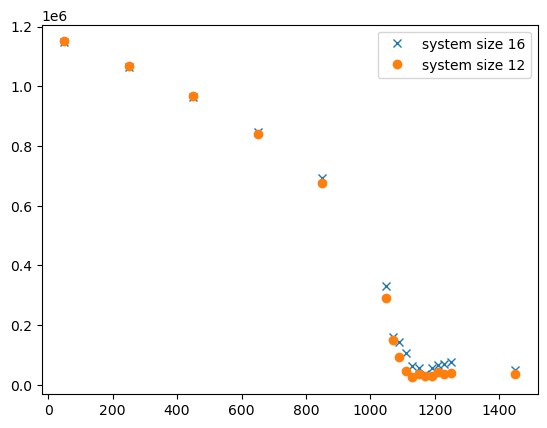

In [94]:
plt.plot(T_combined.value, Ms_combined.value, "x", label="system size 16")
plt.plot(small_system.T.value, small_system.Ms.value, "o", label="system size 12")
plt.legend()

In [96]:
U_binder_combined = np.concat((coarse_sweep.U_binder[:6], fine_sweep.U_binder, coarse_sweep.U_binder[6:]))
U_binder_combined

array([0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667])

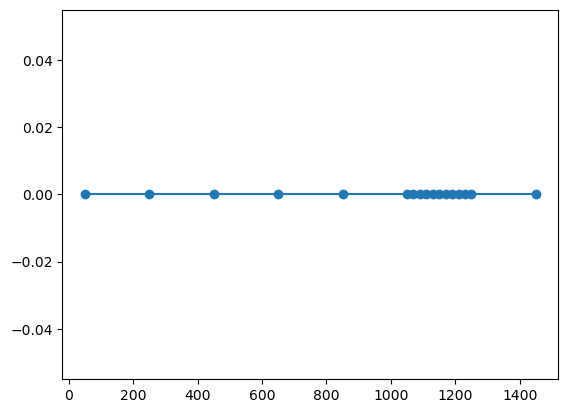

In [103]:
plt.plot(small_system.T.value, small_system.Cv.value, "o-")

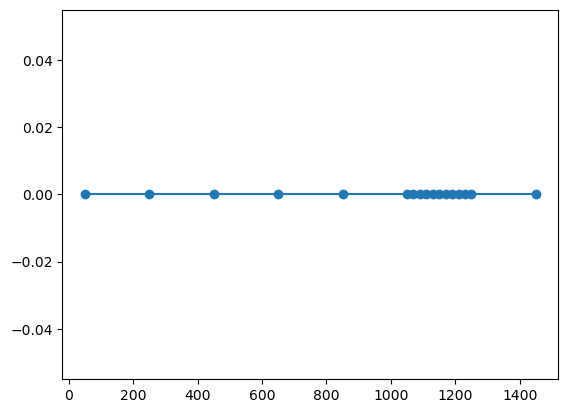

In [102]:
Cv_from_uppasd = []
for run in small_system:
    Cv_from_uppasd.append(run.Cv)

Cv_from_uppasd = me.concat_flat(Cv_from_uppasd)
plt.plot(small_system.T.value, Cv_from_uppasd.value, "o-")

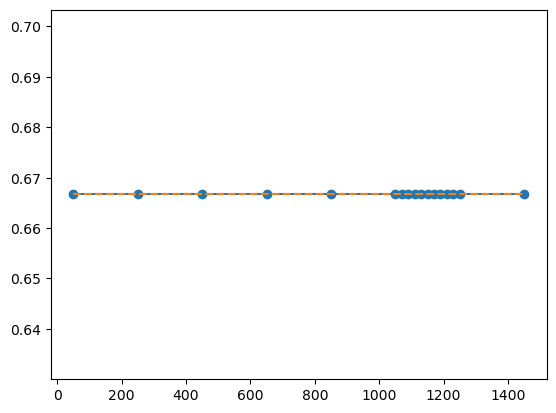

In [108]:
plt.plot(T_combined.value, U_binder_combined, "o-")
plt.plot(small_system.T.value, small_system.U_binder, "--")